## For MADWA project this file reads the Wannier90 Hamiltonian and calculates Berry curvature :D

In [1]:
# Import libraries
import numpy as np
import numpy.linalg as la
import numba as nb
import matplotlib.pyplot as plt
import os
import sys
script_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(script_dir, '..','Src'))  # adjust '..' depending where you are
sys.path.insert(0, project_root)

import MadWa.Tbasic.tbasic as tbasic

import MadWa.Tbasic.tbroutines as tbroutinesÇ
import MadWa.Berry.tberry as tberry
import MadWa.Utils.grids as grid
import time

In [2]:
tb = tbasic.TBasic("./MnSn/wannier90_hr.dat", "./MnSn/wannier90.win")

In [3]:

print(f"Number of Wannier functions: {tb.num_wann}")
print(f"Unit Cell: {tb.recip_cell}")

Number of Wannier functions: 72
Unit Cell: [[ 1.17289628  0.67717197 -0.        ]
 [ 0.          1.35434396  0.        ]
 [ 0.         -0.          1.45642981]]


In [4]:
print(tb.cell)

[[ 5.3569829  0.         0.       ]
 [-2.6784914  4.6392833  0.       ]
 [ 0.         0.         4.314101 ]]


# Berry's curvature implementation

Starting with the implementation of finite differences. This method is more stable when is implemented in the Hamiltonian than in the wave-functions because it avoids the problem of not guaranteed smothness in the phase of the wave functions. The expresion of the Berry tensor is:
$$
\begin{equation}
\Omega_{\mu\nu}^{n}(\mathbf{R}) = i\sum_{n\neq n'}\frac{\braket{n|\partial H/\partial R^{\mu}|n'}\braket{n'|\partial H/\partial R^{\nu}|n}-(\nu \longleftrightarrow\mu)}{(\epsilon_{n}-\epsilon_{n'})^{2}}
\end{equation}
$$
R is a parameter in the parameter space. It is not the R vector that we know
We talked about what happen when you have degenerated states but I don't remember. Eventually we have to deal with them :D

TBerry calculates the total berry curvature in a 

The routines for calculating the Anomalous hall condutivity are some so I put some fucntionalities separated and later the calling of the routine that calls all of them to calculate the AHC that is refine_mesh

In [7]:
#First we can generate the initial kmesh in the Brillouin zone where the Berry curvature is going to be evaluated
Nkx = 10
Nky = 10
Nkz = 10
centers, vertices, weights = grid.coarse_kgrid_cells(Nkx, Nky, Nkz,  tb.cell, Dim2D=False )

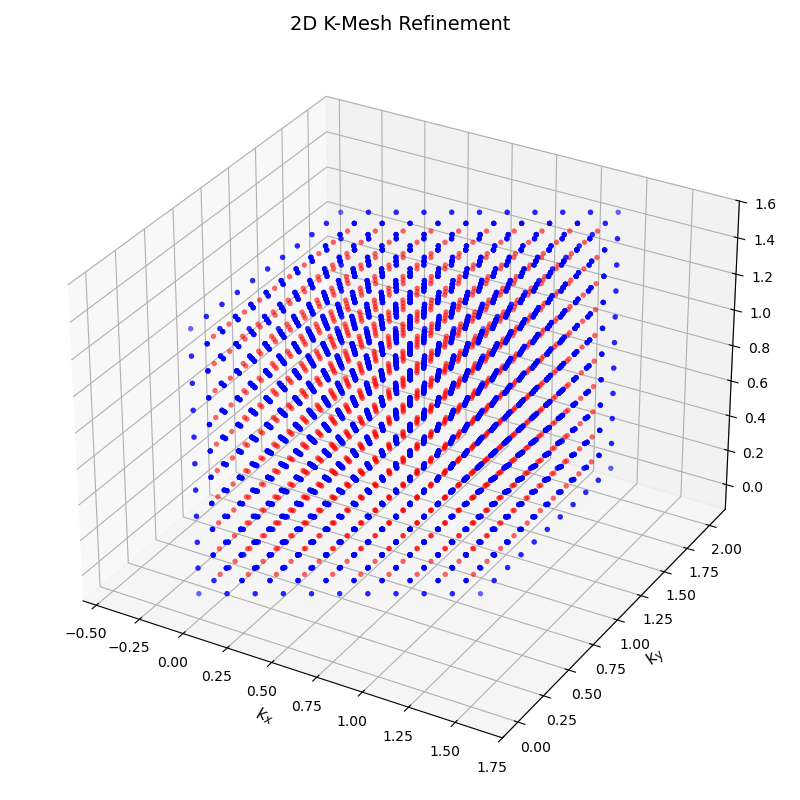

In [8]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget

kmesh = vertices.reshape(-1,3)
# 3. Create the Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

# Scatter plot of the k-points
# s=10 sets a small point size to see the high-density regions clearly
ax.scatter(kmesh[:, 0], kmesh[:, 1], kmesh[:,2], s=15, c='blue', alpha=0.6, edgecolors='none')
#ax.scatter(kmesh[:, 0], kmesh[:, 1], kmesh[:,2], s=15, c='red', alpha=0.6, edgecolors='none')
ax.scatter(centers[:,0], centers[:,1], centers[:,2], s=15, c='red', alpha=0.6, edgecolors='none')

# 4. Styling the graph
plt.title(f'2D K-Mesh Refinement', fontsize=14)
plt.xlabel('$k_x$', fontsize=12)
plt.ylabel('$k_y$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.axis('equal')  # Important to keep the aspect ratio of the Brillouin Zone

# Optional: Add a boundary box or highlight the origin
# plt.axhline(0, color='black', lw=1, alpha=0.3)
# plt.axvline(0, color='black', lw=1, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
#Second we can calculate the berry curvature in all the centers of the cells.
#It is related to the original function but in this case it returns the components of the curvature tensor in form of vector 
#for all the centers that is useful given the way that the refinement works

fermi_energy =8.0848
vect_omg_xy, vect_omg_xz, vect_omg_yz = tberry.berry_coarse(centers, tb.H_ij, tb.rvects, tb.deg, tb.cell, fermi_energy)

In [10]:
#Until here the AHC can be evaluated in the selected centers
sigma_xy, sigma_xz, sigma_yz = tberry.AHC_ref(vect_omg_xy, vect_omg_yz, vect_omg_xz, weights, tb.cell, Dim2D = False)
sigma_xy, sigma_xz, sigma_yz

total cells: 1000


(0.4412503794288928, 5.038198220436583, -0.2701890830325841)

In [11]:
# Nevertheless given the difficulty of getting converging results for the AHC sometimes is necessary a lot of points in this sense we can use refinament
# the first step is to divide the cells created before acording some criteria in this case the first index is the target cell

#IMPORTANT: This function is more useful as an internal function of the algorithm but it is good for you to know that it exists :D
nkx =2
nky=2
nkz=2
child_vertices, child_centres, child_weights = grid.subdivide_cells(0, vertices, centers, weights, nkx, nky, nkz, False)

In [12]:
# If we want to calculate the AHC using the refinement just call the refine_mesh function
sigma_xy, sigma_xz, sigma_yz = tberry.refine_mesh(Nkx, Nky, Nkz,tb.H_ij, tb.rvects, tb.deg, tb.cell, fermi_energy, 100, nkx,nky,nkz, False, max_level=2)

Converged at level 0
total cells: 1000


In [13]:
sigma_xy, sigma_xz, sigma_yz

(0.4412503794288928, 5.038198220436583, -0.2701890830325841)